In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters
from qiskit.circuit.library import RealAmplitudes, EfficientSU2
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.minimum_eigensolvers import SamplingVQE
from qiskit.primitives import Sampler
import matplotlib.pyplot as plt

In [10]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)

    penalty_back = 10
    penalty_redun = 10
    penalty_olap_1 = 10
    penalty_olap_2 = 1
    penalty_olap_3 = 10
    penalty_olap_4 = 1

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun, penalty_olap_1, penalty_olap_2, penalty_olap_3, penalty_olap_4)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [11]:
main_seq = "LFLF" # 6MVZ
protein_folding_problem = build_pf(main_seq)
qubit_op = protein_folding_problem.qubit_op()

In [12]:
print("Number of qubits: ", qubit_op.num_qubits)
print("Number of terms: ", len(qubit_op))

Number of qubits:  9
Number of terms:  107


In [13]:
def run_vqe(qubit_op):
    # set classical optimizer
    optimizer = COBYLA(maxiter=100)

    # set variational ansatz
    ansatz = RealAmplitudes(reps=1)

    counts = []
    values = []

    def store_intermediate_result(eval_count, parameters, mean, std):
        counts.append(eval_count)
        values.append(mean)

    # initialize VQE using CVaR with alpha = 0.1
    vqe = SamplingVQE(
        Sampler(),
        ansatz=ansatz,
        optimizer=optimizer,
        aggregation=0.1,
        callback=store_intermediate_result,
    )

    raw_result = vqe.compute_minimum_eigenvalue(qubit_op)

    return raw_result, counts, values

In [14]:
raw_result, counts, values = run_vqe(qubit_op)

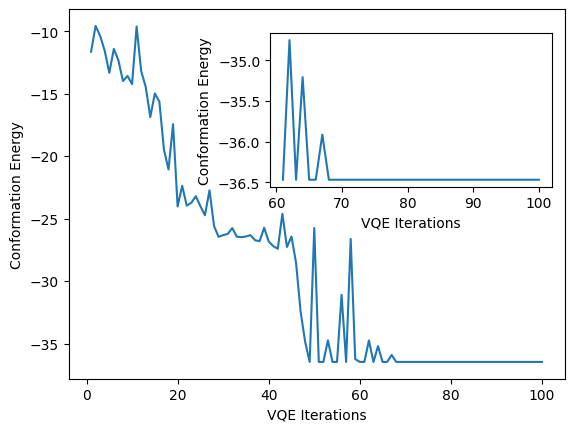

In [17]:
fig = plt.figure()

plt.plot(counts, values)
plt.ylabel("Conformation Energy")
plt.xlabel("VQE Iterations")

fig.add_axes([0.44, 0.51, 0.44, 0.32])

plt.plot(counts[60:], values[60:])
plt.ylabel("Conformation Energy")
plt.xlabel("VQE Iterations")
plt.show()

Best turn bitstring:  111011010
Best turn sequence:  [0, 9, 7]


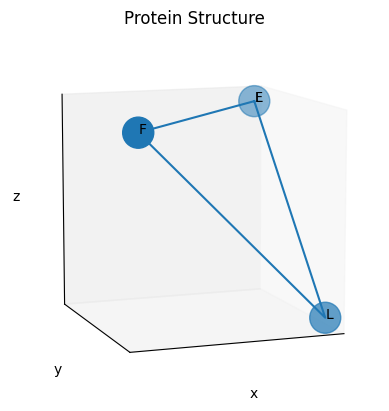

In [16]:
result = protein_folding_problem.interpret(raw_result)
print("Best turn bitstring: ", result.solution_bitstring)
print("Best turn sequence: ", result.turn_sequence)
fig = result.get_figure(ticks=False, grid=True)
fig.get_axes()[0].view_init(elev=10, azim=70)